<a href="https://colab.research.google.com/github/Tedodor423/bms-collab-notebooks/blob/main/stats/3.3_ttest/3.3.6_ttest_oneSample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# One sample t-test

*A one-sample $t$-test tests whether the mean of a single sample differs from a specified population mean.*


### Set up Python libraries

As usual, run the code cell below to import the relevant Python libraries

In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.simplefilter('ignore', category=FutureWarning)

## Example: Rowers' Height

<img src="https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/images/rowingTeam.png" width=50% >

An observer notes that the men on a particular rowing team appear quite tall, and hypothesises that rowers are generally taller than average, perhaps because taller people can row faster.

The heights (in cm) of eight men on a rowing team are recorded.

**Question:** use a one-sample $t$-test to determine whether the mean height of the rowing team is significantly greater than the average height of men in the UK (175 cm).

*Notes:*
- This is a **one-sample** design: the sample mean is compared to a known population value.
- Height is a continuous variable that is often approximately Normally distributed in the population.
- The sample size is small ($(n = 8)$), the population standard deviation is unknown and must be estimated from the sample.
- Under these conditions, a **one-sample $t$-test** is an appropriate choice.
- The hypothesis is **directional** (rowers are taller than average), which justifies a **one-sided** test.

*Practical steps*
1. Inspect the data to check for extreme outliers and approximate Normality.  
2. State the formal hypotheses.  
3. Report the descriptive statistics (sample mean, standard deviation, and sample size).  
4. Run the one-sample $t$-test.  
5. Draw conclusions.


### 1. Inspect the data

Let's load the data as a Pandas dataframe, and plot them to get a sense for their distribution (is it normal?) and any outliers

In [2]:
heights = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/rowersHeights.csv')
display(heights)

,height
0,180.7
1,185.1
2,198.1
3,175.3
4,181.3
5,179.4
6,166.5
7,176.9


**Plot the data**

As before, a KDE plot is useful to show the shape of the distribution, and a rug plot to show individual values, as the sample size is so small.                                                                                                                        

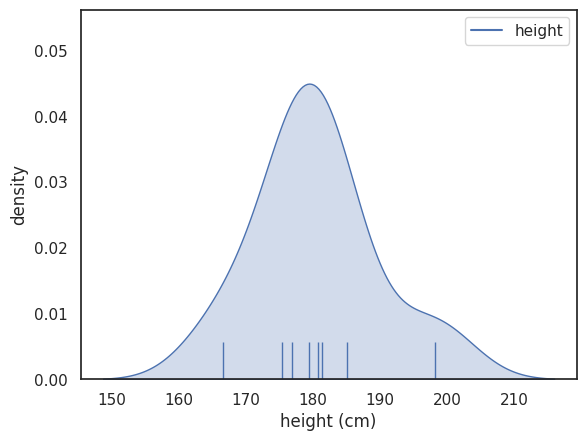

In [3]:
plot = sns.kdeplot(data = heights, fill=True)
sns.rugplot(data = heights, height=0.1)
plt.xlabel("height (cm)", fontsize = 12)
plt.ylabel("density", fontsize = 12)
plt.show()

As usual, it's difficult to say if the data are normally distributed from a plot of a small sample - they don't look too bad although there is one very tall outlier. However, height is generally normally distributed so let's go ahead and use the t-test.

### 2. Hypotheses


$\mathcal{H_o}$: the mean height of rowers is greater than the population average of 175cm

$\mathcal{H_a}$: the mean higher of rowers is not different from the population average of 175cm
    
This is a one-tailed test as the observer's hypothesis (described above) is directional - she thinks taller people are more likely to be good rowers

We will test at the $\alpha = 0.05$ significance level

### 3. Descriptive Statistics

First, we obtain the relevant desriptive statistics. By relevant, I mean the ones that go into the equation for the t-test:

$ t = \frac{\bar{x}}{\frac{s}{\sqrt{n}}} $

This would be the sample mean $\bar{x}$, the standard deviation $s$, and the sample size $n$. These can all be read out from the ```df.describe()``` function



In [4]:
heights.describe()

,height
count,8.000000
mean,180.412500
std,9.013868
min,166.500000
25%,176.500000
50%,180.050000
75%,182.250000
max,198.100000


It appears that the mean height of the rowers (180.4 cm) is above the population mean of 175 cm.

Is this a large difference? The sample mean is less than one standard deviation above the population mean: the sample standard deviation is \(s = 8.4\) cm, and the difference in means is \(180.4 - 175 = 5.4\) cm. According to the Normal distribution, a person with this height would be taller than about 75% of the population—clearly tall, but not exceptionally so.

However, another key consideration is the variability in the dataset. If the rowers are consistently tall (that is, if most of them are taller than average), then as a group they may be significantly taller than the population mean. To determine whether this difference is larger than we would expect by chance, we need to formally carry out the statistical test.

### 4. Carry out the test

We carry out the test using the function `stats.ttest_1samp()` from `scipy.stats`.

The inputs to `stats.ttest_1samp()` are:
- the sample to be tested (the values in the `heights` column of our Pandas DataFrame);
- the reference value to compare against (the average height of men in the UK, 175 cm);
- the argument `alternative='greater'`, which specifies a one-tailed test in which the mean of the sample (`heights`) is expected to be greater than the reference value (175 cm).

The outputs are the value of the test statistic ($t = 1.70$) and the associated p-value ($p = 0.067$). Because this p-value is greater than our chosen significance level ($\alpha = 0.05$), we do not find a statistically significant difference.

In [5]:
stats.ttest_1samp(heights, 175, alternative='greater')

TtestResult(statistic=array([1.6983676]), pvalue=array([0.06662235]), df=array([7]))

**Degrees of freedom**

In a scientific write-up we also need to report the degrees of freedom of the test. This tells us how many observations (data-points) the test was based on, corrected for the number of means we had to estimate from the data in order to do the test.

In the case of the one sample t-test $df = n-1$ so in this case, df=7 and we can report out test results as:

$t(7) = 1.70, p=0.067$ (one-tailed)

### 5. Draw conclusions

Our t value of 1.67 means that the difference between the mean height of the rowers and the standard value (175cm, the mean height of British men) is 1.67 times the standard error (where $ SE = \frac{s}{\sqrt{n}}$).

Such a large difference (in the expected direction) would occur 0.067 (6.7%) of the time due to chance if the null hypothesis were true (rowers were no taller than other men), hence the p value of 0.067. This is higher than our alpha value (0.05) so the test is not significant.

This diagram shows the expected distribution of t-values if the null were true, with our obtained t-value marked:

<img src="https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook/main/images/ttestRowing.png" width=50% alt="There should be a picture of the t-distribution here" >

***As p>0.05 the test is not significant and we fail to reject the null hypothesis. There is not sufficient evidence to support the hypothesis that rowers are taller than average.***

## Write-up
<br>

<div style = "    padding-top: 10px;
    padding-bottom: 10px;
    padding-left: 10px;
    padding-right: 10px;
    box-shadow: 0px 8px 16px 0px rgba(0,0,0,0.2);
    vertical-align: middle;">
    
Above, I walked you through how to run the t-test and why we make different choices.
    
In this section we practice writing up our analysis in the correct style for a scientific report.
    
Replace the XXXs with the correct values!    

</div>

<br>

To test the hypothesis that rowers are taller than average, we measaured the heights of 8 male rowers and compared to the national value for mean height of British men (obtained from Wikipedia): 175cm.

The data are shown below:

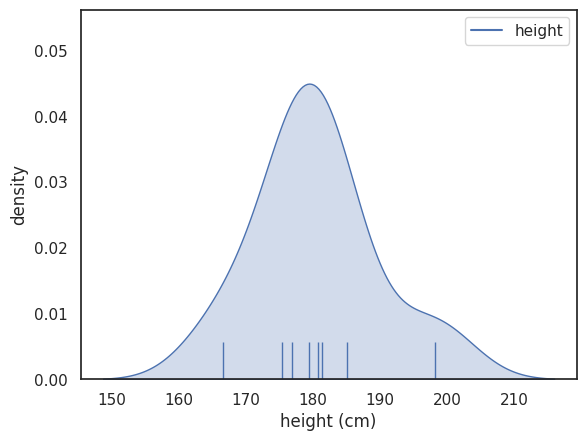

In [6]:
plot = sns.kdeplot(data = heights, fill=True)
sns.rugplot(data = heights, height=0.1)
plt.xlabel("height (cm)", fontsize = 12)
plt.ylabel("density", fontsize = 12)
plt.show()

The mean height of the rowers was XXX.X cm and the standard deviation was X.XX cm.

In [7]:
heights = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/rowersHeights.csv')
heights.describe()

,height
count,8.000000
mean,180.412500
std,9.013868
min,166.500000
25%,176.500000
50%,180.050000
75%,182.250000
max,198.100000


We used a one-sample t-test (alpha = X, XX tailed). The use of the t-test (assumption of normality) was justified theoretically on the grounds that heights are typically normally distributed.

In [8]:
stats.ttest_1samp(heights, 175, alternative='greater')

TtestResult(statistic=array([1.6983676]), pvalue=array([0.06662235]), df=array([7]))

The results of the t-test $t(XX) =$ X.XX, $p=$X.XX (XX-tailed) suggest that there is insufficient evidence ot reject the null and we cannot conclude that rowers are taller than average.